1. Carregar les dades

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the prepared bank dataset
data_path = "../../data_prepared/bank_term_deposit_prepared.csv"
df = pd.read_csv(data_path)

# Display basic structural information
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows of the dataset:")
print(df.head())

# 2. ¡AQUÍ ESTÁ EL TRUCO! Filtrar solo las filas etiquetadas y sobreescribir 'df'
df = df[df['split'] == 'labeled'].copy()

# Eliminar la columna 'split' si ya no la necesitas para entrenar
df = df.drop(columns=['split'])

# Check target variable distribution to verify imbalance
# Assuming 'y' or 'deposit' is the target column (adjust name if different)
target_column = 'y'
print("\nTarget distribution:")
print(df[target_column].value_counts(normalize=True))

Dataset shape: (3063, 23)

First 5 rows of the dataset:
   id    split  age          job   marital  education default  balance  \
0   1  labeled   31   management   married   tertiary      no    460.0   
1   2  labeled   34  blue-collar   married  secondary      no   1826.0   
2   3  labeled   50  blue-collar   married  secondary      no    290.0   
3   4  labeled   42       admin.  divorced  secondary      no   1077.0   
4   5  labeled   47     services    single  secondary      no     41.0   

  housing loan  ... duration  campaign pdays  previous  poutcome   y  \
0      no   no  ...     13.0        14    -1         0   unknown  no   
1     yes   no  ...    203.0         2    -1         0   unknown  no   
2     yes   no  ...    226.0         3    -1         0   unknown  no   
3     yes   no  ...    213.0         1    -1         0   unknown  no   
4     yes   no  ...    298.0         1    -1         0   unknown  no   

   was_contacted_before campaign_intensity     age_group  quarter 

2. Feature Engineering

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Identify features and target
X = df.drop(columns=[target_column])

# Convert target to binary
y = df[target_column].map({
    'no': 0,
    'yes': 1
})

# Separate numerical and categorical columns
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Define preprocessing pipelines
num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Combine into a single preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ]
)

3. Train / Test Split

In [3]:
from sklearn.model_selection import train_test_split

# Define train-test split ratio (e.g., 80% train, 20% test)
test_size_ratio = 0.20
random_seed = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size_ratio,
    stratify=y,
    random_state=random_seed
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Train target ratio:\n{y_train.value_counts(normalize=True)}")

Training set shape: (1605, 21)
Testing set shape: (402, 21)
Train target ratio:
y
0    0.913396
1    0.086604
Name: proportion, dtype: float64


4. Cross-validation

In [4]:
from sklearn.model_selection import StratifiedKFold

# Define the stratified cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)

# Scoring metrics to track
scoring_metrics = ['precision', 'recall', 'f1']

5. Baseline

In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate

# Baseline model: predicts the most frequent class
baseline_model = DummyClassifier(strategy='most_frequent')

# Evaluate baseline using cross-validation
baseline_cv_results = cross_validate(
    baseline_model, X_train, y_train,
    cv=cv_strategy, scoring=scoring_metrics, return_train_score=True
)

print(f"Baseline Train F1-Score: {baseline_cv_results['train_f1'].mean():.4f}")
print(f"Baseline Validation F1-Score: {baseline_cv_results['test_f1'].mean():.4f}")

Baseline Train F1-Score: 0.0000
Baseline Validation F1-Score: 0.0000


C:\Users\fundacion\PycharmProjects\cifo_machine_learning_2026\.venv_py312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\fundacion\PycharmProjects\cifo_machine_learning_2026\.venv_py312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\fundacion\PycharmProjects\cifo_machine_learning_2026\.venv_py312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to contr

6. Logistic Regression

C:\Users\fundacion\PycharmProjects\cifo_machine_learning_2026\.venv_py312\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Best Logistic Regression Params: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}
Best CV F1-Score: 0.7651


C:\Users\fundacion\PycharmProjects\cifo_machine_learning_2026\.venv_py312\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\fundacion\PycharmProjects\cifo_machine_learning_2026\.venv_py312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\fundacion\PycharmProjects\cifo_machine_learning_2026\.venv_py312\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty'

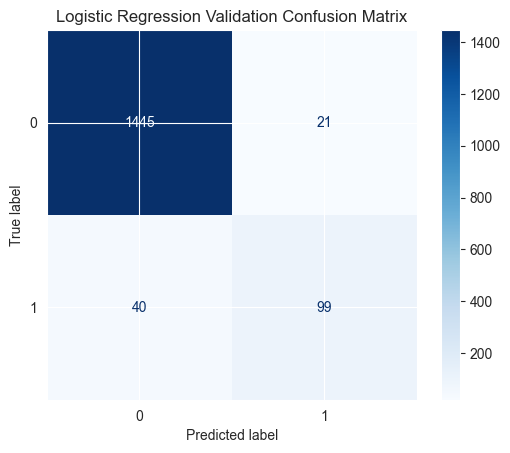

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Complete pipeline wrapping preprocessing and the model
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=random_seed))
])

# Define hyperparameter grid ensuring compatible combinations
lr_param_grid = [
    {
        'classifier__penalty': ['l2'],
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__solver': ['lbfgs', 'saga']
    },
    {
        'classifier__penalty': ['l1'],
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__solver': ['saga']
    }
]

# Execute Grid Search
lr_grid_search = GridSearchCV(
    lr_pipeline, param_grid=lr_param_grid,
    cv=cv_strategy, scoring='f1', return_train_score=True, n_jobs=-1
)
lr_grid_search.fit(X_train, y_train)

print(f"Best Logistic Regression Params: {lr_grid_search.best_params_}")
print(f"Best CV F1-Score: {lr_grid_search.best_score_:.4f}")

# Generate validation predictions using cross_val_predict with the best estimator
best_lr_model = lr_grid_search.best_estimator_
y_val_pred_lr = cross_val_predict(best_lr_model, X_train, y_train, cv=cv_strategy)

# Plot Confusion Matrix
cm_lr = confusion_matrix(y_train, y_val_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp_lr.plot(cmap=plt.cm.Blues)
plt.title("Logistic Regression Validation Confusion Matrix")
plt.show()

7. Random Forest y Gradient Boosting

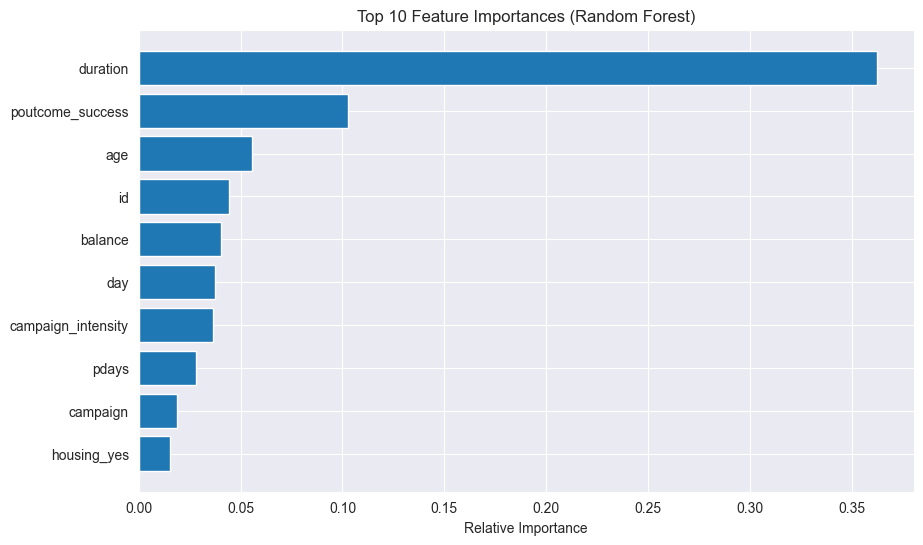

In [7]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=random_seed))
])

rf_param_dist = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5, 10]
}

rf_random_search = RandomizedSearchCV(
    rf_pipeline, param_distributions=rf_param_dist, n_iter=5,
    cv=cv_strategy, scoring='f1', random_state=random_seed, n_jobs=-1
)
rf_random_search.fit(X_train, y_train)

# Feature Importance extraction for Random Forest
best_rf = rf_random_search.best_estimator_
encoded_features = num_features + list(best_rf.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(cat_features))
importances = best_rf.named_steps['classifier'].feature_importances_

# Plot Top 10 Features
indices = np.argsort(importances)[-10:]
plt.figure(figsize=(10, 6))
plt.title("Top 10 Feature Importances (Random Forest)")
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [encoded_features[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

8. TabPFN

In [18]:
# ==========================================================
# Authentication
# ==========================================================

import os

os.environ["TABPFN_TOKEN"] = "tabpfn_sk_HegmzPRECBX7B-KslW6Mxlm54tSi0dp5VkBSsBQkdMU"

# ==========================================================
# 1. Imports
# ==========================================================

from tabpfn import TabPFNClassifier

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns
import matplotlib.pyplot as plt


# ==========================================================
# 2. Prepare data
# ==========================================================

X_train_tabpfn = X_train.copy()
X_test_tabpfn = X_test.copy()

# Convert categorical columns to category dtype
for col in cat_features:
    if X_train_tabpfn[col].dtype == "object":
        X_train_tabpfn[col] = X_train_tabpfn[col].astype("category")
        X_test_tabpfn[col] = X_test_tabpfn[col].astype("category")


# ==========================================================
# 3. Create TabPFN model
# ==========================================================

tabpfn_model = TabPFNClassifier(
    device="cpu",
    random_state=random_seed
)


# ==========================================================
# 4. Cross Validation Predictions
# ==========================================================

tabpfn_cv_predictions = cross_val_predict(
    estimator=tabpfn_model,
    X=X_train_tabpfn,
    y=y_train,
    cv=cv_strategy,
    method="predict",
    n_jobs=1          # recomendado para TabPFN
)


# ==========================================================
# 5. Evaluation Metrics
# ==========================================================

precision = precision_score(
    y_train,
    tabpfn_cv_predictions,
    zero_division=0
)

recall = recall_score(
    y_train,
    tabpfn_cv_predictions,
    zero_division=0
)

f1 = f1_score(
    y_train,
    tabpfn_cv_predictions,
    zero_division=0
)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\nClassification Report\n")
print(classification_report(
    y_train,
    tabpfn_cv_predictions,
    zero_division=0
))


# ==========================================================
# 6. Confusion Matrix
# ==========================================================

cm = confusion_matrix(
    y_train,
    tabpfn_cv_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("TabPFN - Confusion Matrix")

plt.tight_layout()
plt.show()

tabpfn-v3-classifier-v3_default.ckpt:   0%|          | 0.00/213M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]

RuntimeError: Running on CPU with more than 1000 samples is not allowed by default due to slow performance.
To override this behavior, set the environment variable TABPFN_ALLOW_CPU_LARGE_DATASET=1 or set ignore_pretraining_limits=True.
Alternatively, consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client

9. Predicted Probabilities

In [1]:
# Get predicted probabilities for the validation sets using Logistic Regression
y_val_proba_lr = cross_val_predict(
    best_lr_model, X_train, y_train, cv=cv_strategy, method="predict_proba"
)

# Extract probabilities for the positive class (column 1)
positive_class_probas = y_val_proba_lr[:, 1]

# Plot the distribution of probabilities to check calibration/confidence
plt.figure(figsize=(8, 5))
sns.histplot(positive_class_probas, kde=True, bins=30)
plt.title("Distribution of Predicted Probabilities (Positive Class)")
plt.xlabel("Probability")
plt.ylabel("Count")
plt.show()

NameError: name 'cross_val_predict' is not defined

10. Comparació final (Comparación final y Testeo)

In [2]:
from sklearn.metrics import classification_report

# Compare CV results (Example using F1-score)
print("=== FINAL REVIEWS & COMPARISONS (CV F1-SCORES) ===")
print(f"Baseline Classifier : {baseline_cv_results['test_f1'].mean():.4f}")
print(f"Logistic Regression : {lr_grid_search.best_score_:.4f}")
print(f"Random Forest       : {rf_random_search.best_score_:.4f}")

# Choose the best architecture (Assuming Random Forest performed best)
final_chosen_model = best_rf

# Evaluate on the completely untouched Test Set
y_test_pred = final_chosen_model.predict(X_test)

print("\n=== FINAL TEST SET EVALUATION ===")
print(classification_report(y_test, y_test_pred))

=== FINAL REVIEWS & COMPARISONS (CV F1-SCORES) ===


NameError: name 'baseline_cv_results' is not defined